# **TS2:** Algoritmo para calcular la DFT.
## Mariano Pittaluga.

### Consigna:
Desarrollar un algoritmo que calcule la transformada discreta de Fourier (DFT):

$$
X_k = \sum_{n=0}^{N-1} x_n \, e^{-j 2\pi k n / N}
$$

XX = dft( xx )

xx: Señal a analizar, una matriz (Nx1) de números reales. 

XX: DFT de xx, una matriz (Nx1) de números complejos.

Ayuda:
- Aprovechando que tenemos un generador de senoidales funcionando, y recordando que la DFT de una senoidal de frecuencia f0, será una delta de Kronecker posicionada en la frecuencia f0. Validen sus funciones con esta experiencia.

Bonus:
- Probar las mismas experiencias con la transformada rápida de Fourier (DFT rápida se llama FFT).
- Calcular la DFT de una señal aleatoria, por ejemplo ruido uniforme de varianza σ² = 4.

## Resolución: 

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

# Condiciones de muestreo
N    = 1000 
fs   = 1000 

### Función Generador de Señales:

In [37]:
def signal( wave ='sin', vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs, duty=0.5 ):
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    
    match wave:
        case 'sine':
            xx = vmax * np.sin( 2 * np.pi * ff * tt + ph) + dc
        case 'square':
            xx = vmax * sig.square( 2 * np.pi * ff * tt + ph, duty = duty) + dc
        case 'triangle':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph, width=0.5) + dc
        case 'sawtooth':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph) + dc
        case _:
            raise ValueError(f"Tipo '{wave}' no reconocido.")
    
    return tt, xx

### Función DFT:

In [38]:
def dft(x):
    N  = len(x)
    n  = np.arange(N)
    k  = n.reshape((N, 1))
    e  = np.exp(-2j * np.pi * k * n / N)
    Xk = np.dot(e, x)
    return Xk

### Señal de prueba:

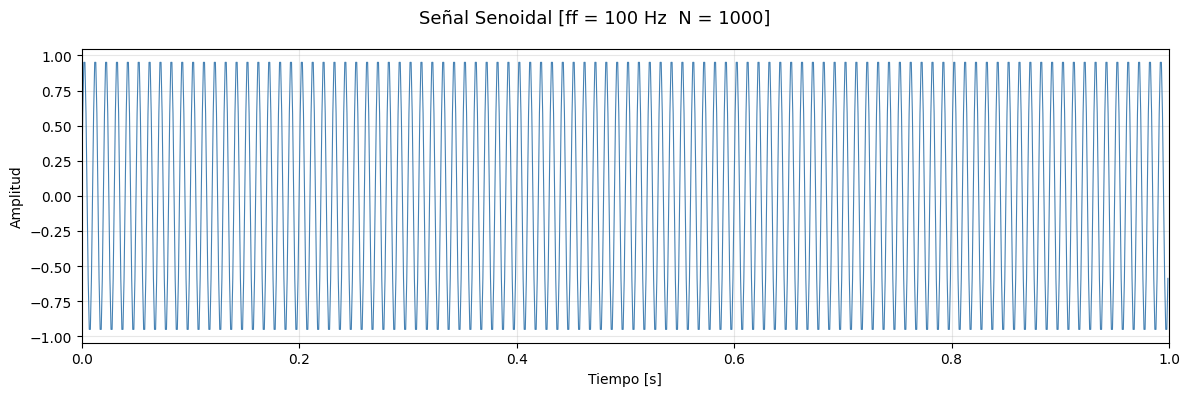

In [39]:
ff   = 100 #Hz
vmax = 1 #V
t, x = signal(wave='sine', vmax=vmax, ff=ff, nn=N, fs=fs)

#Grafico
fig1, ax1 = plt.subplots(figsize=(12, 4))
fig1.suptitle(f"Señal Senoidal [ff = {ff} Hz  N = {N}]", fontsize=13)

ax1.plot(t, x, color='steelblue', linewidth=0.8)
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.set_xlim(0, len(x)/fs)
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.subplots_adjust(top=0.88)

### Componentes de la DFT:

In [40]:
xt = x.reshape((N, 1)) # La funcion DFT usa (N,1)
Xk = dft(xt)
k  = np.arange(N) # Tiene simetria con respecto a N/2
f  = k * fs / N
               
modulo     = np.abs(Xk[k])  / N  # Normalizamos
fase       = np.angle(Xk[k]) # En Radianes
parte_real = np.real(Xk)
parte_imag = np.imag(Xk)

#### Módulo y Fase:

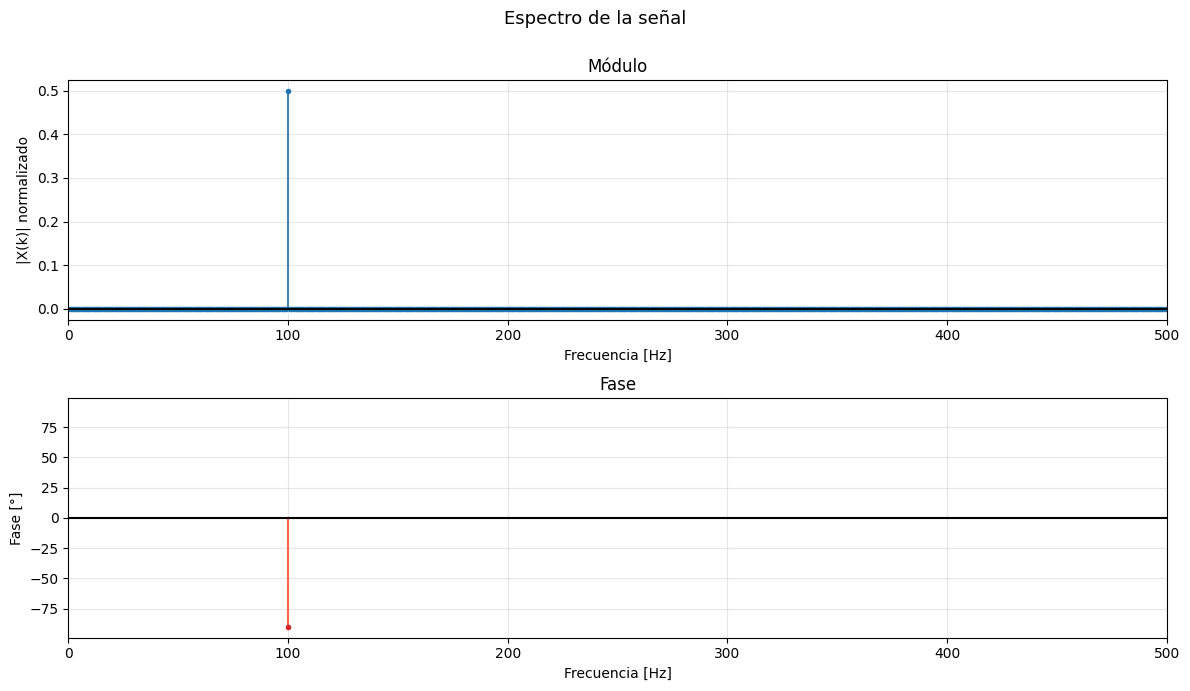

In [41]:
fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(12, 7))
fig2.suptitle("Espectro de la señal", fontsize=13)

ax2.stem(f, modulo, linefmt='steelblue', markerfmt='C0.', basefmt='k')
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("|X(k)| normalizado")
ax2.set_title("Módulo")
ax2.set_xlim(0, fs/2)
ax2.grid(True, alpha=0.3)

# Elimino los datos de fase que no importan
umbral    = modulo.max() * 1e-3 
fase_plot = np.where(modulo > umbral, fase, np.nan)

ax3.stem(f, np.degrees(fase_plot), linefmt='tomato', markerfmt='C3.', basefmt='k')
ax3.set_xlabel("Frecuencia [Hz]")
ax3.set_ylabel("Fase [°]")
ax3.set_title("Fase")
ax3.set_xlim(0, fs/2)
ax3.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.subplots_adjust(top=0.88)

#### Parte Real e Imaginaria:

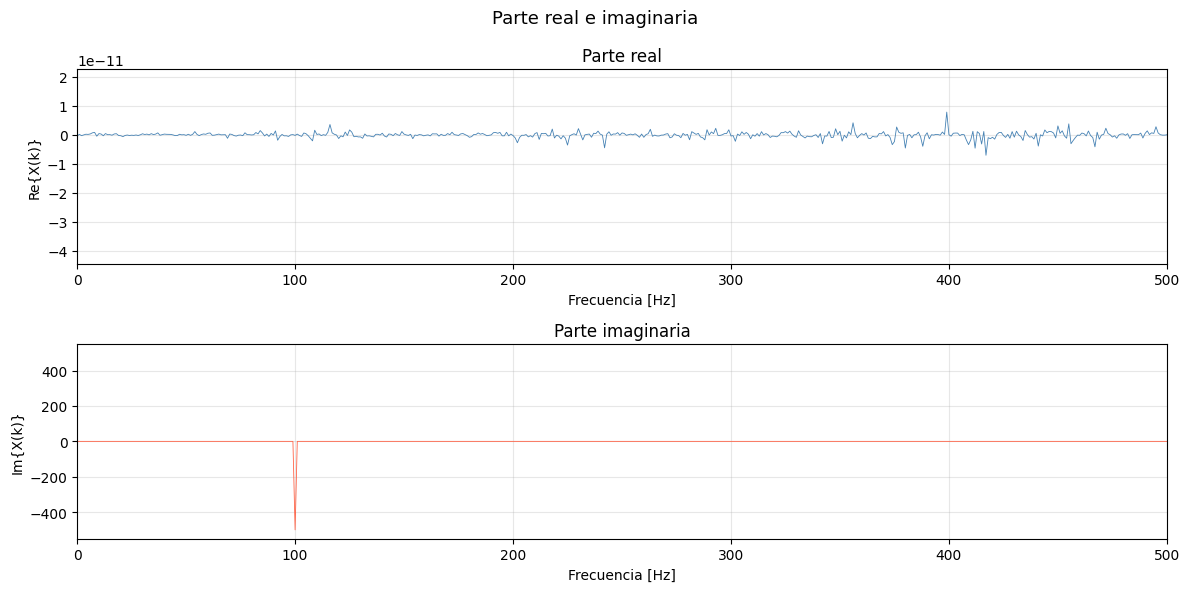

In [42]:
fig3, (ax4, ax5) = plt.subplots(2, 1, figsize=(12, 6))
fig3.suptitle("Parte real e imaginaria", fontsize=13)

ax4.plot(f, parte_real, color='steelblue', linewidth=0.6)
ax4.set_xlabel("Frecuencia [Hz]")
ax4.set_ylabel("Re{X(k)}")
ax4.set_title("Parte real")
ax4.set_xlim(0, fs/2)
ax4.grid(True, alpha=0.3)

ax5.plot(f, parte_imag, color='tomato', linewidth=0.6)
ax5.set_xlabel("Frecuencia [Hz]")
ax5.set_ylabel("Im{X(k)}")
ax5.set_title("Parte imaginaria")
ax5.set_xlim(0, fs/2)
ax5.grid(True, alpha=0.3)

fig3.tight_layout()
fig3.subplots_adjust(top=0.88)
plt.show()

## Bonus:
## Repetimos con FFT:
### Componentes de la DFT:

In [43]:
Xk = np.fft.fft(x)
k  = np.arange(N) # Tiene simetria con respecto a N/2
f  = k * fs / N
               
modulo     = np.abs(Xk[k])  / N  # Normalizamos
fase       = np.angle(Xk[k]) # En Radianes
parte_real = np.real(Xk)
parte_imag = np.imag(Xk)

#### Módulo y Fase:

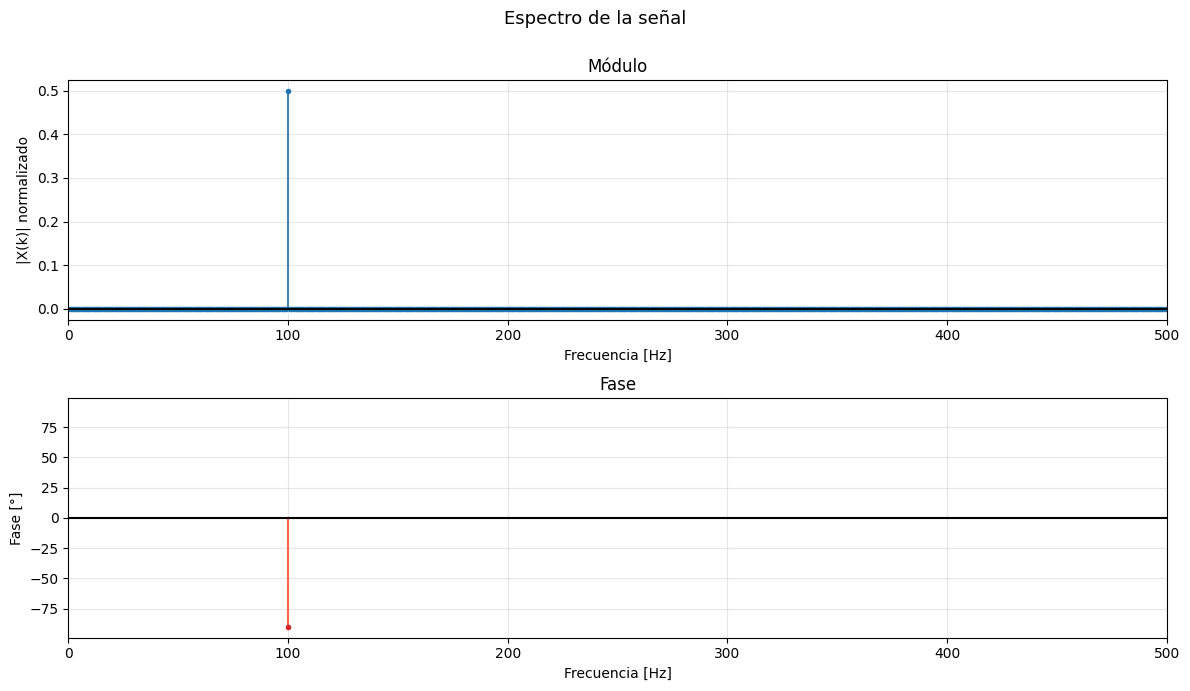

In [44]:
fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(12, 7))
fig2.suptitle("Espectro de la señal", fontsize=13)

ax2.stem(f, modulo, linefmt='steelblue', markerfmt='C0.', basefmt='k')
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("|X(k)| normalizado")
ax2.set_title("Módulo")
ax2.set_xlim(0, fs/2)
ax2.grid(True, alpha=0.3)

# Elimino los datos de fase que no importan
umbral    = modulo.max() * 1e-3 
fase_plot = np.where(modulo > umbral, fase, np.nan)

ax3.stem(f, np.degrees(fase_plot), linefmt='tomato', markerfmt='C3.', basefmt='k')
ax3.set_xlabel("Frecuencia [Hz]")
ax3.set_ylabel("Fase [°]")
ax3.set_title("Fase")
ax3.set_xlim(0, fs/2)
ax3.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.subplots_adjust(top=0.88)

#### Parte Real e Imaginaria:

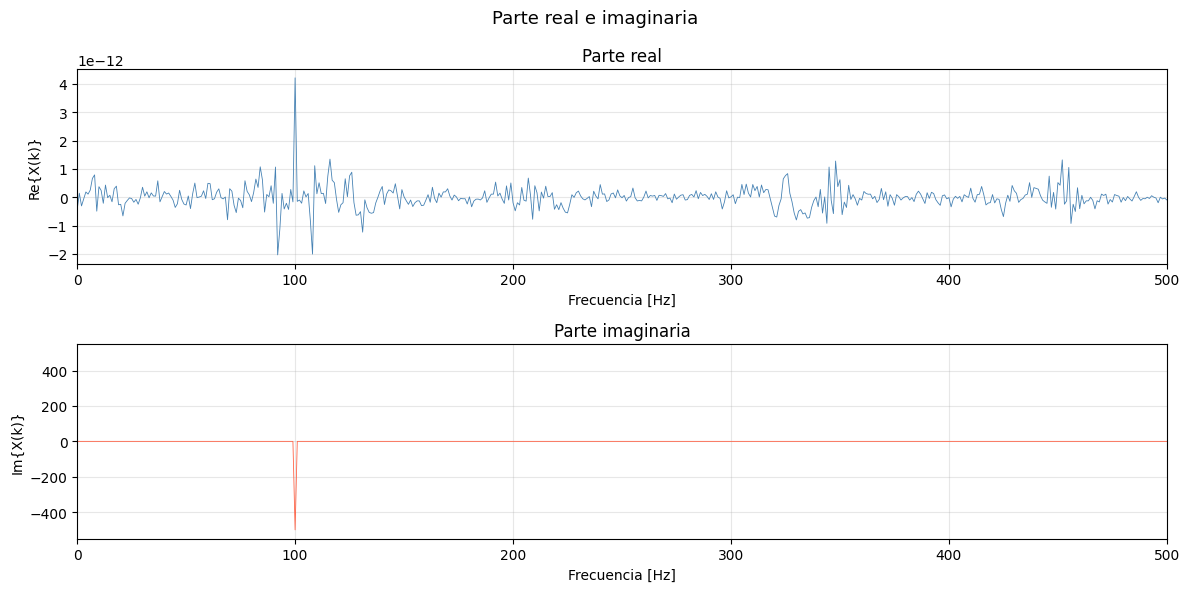

In [45]:
fig3, (ax4, ax5) = plt.subplots(2, 1, figsize=(12, 6))
fig3.suptitle("Parte real e imaginaria", fontsize=13)

ax4.plot(f, parte_real, color='steelblue', linewidth=0.6)
ax4.set_xlabel("Frecuencia [Hz]")
ax4.set_ylabel("Re{X(k)}")
ax4.set_title("Parte real")
ax4.set_xlim(0, fs/2)
ax4.grid(True, alpha=0.3)

ax5.plot(f, parte_imag, color='tomato', linewidth=0.6)
ax5.set_xlabel("Frecuencia [Hz]")
ax5.set_ylabel("Im{X(k)}")
ax5.set_title("Parte imaginaria")
ax5.set_xlim(0, fs/2)
ax5.grid(True, alpha=0.3)

fig3.tight_layout()
fig3.subplots_adjust(top=0.88)
plt.show()

## DFT de Señal Aleatoria:
### Función Ruido Uniforme:
Del ruido uniforme sabemos que:
$$
\mu = \frac{a+b}{2}, \quad \sigma = \frac{b-a}{\sqrt{12}}, \quad
$$
Entonces despejamos los limites:
$$
a = \mu - \sqrt{3}\,\sigma, \quad b = \mu + \sqrt{3}\,\sigma
$$
Finalmente:

In [46]:
def unoise(nn=1000, fs=1000, mean=0, std=1):
    a = mean - np.sqrt(3) * std
    b = mean + np.sqrt(3) * std
    tt  = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    ww  = np.random.uniform(a, b, nn)
    return tt, ww

### DFT del Ruido Uniforme ($\sigma^2 = 4$):

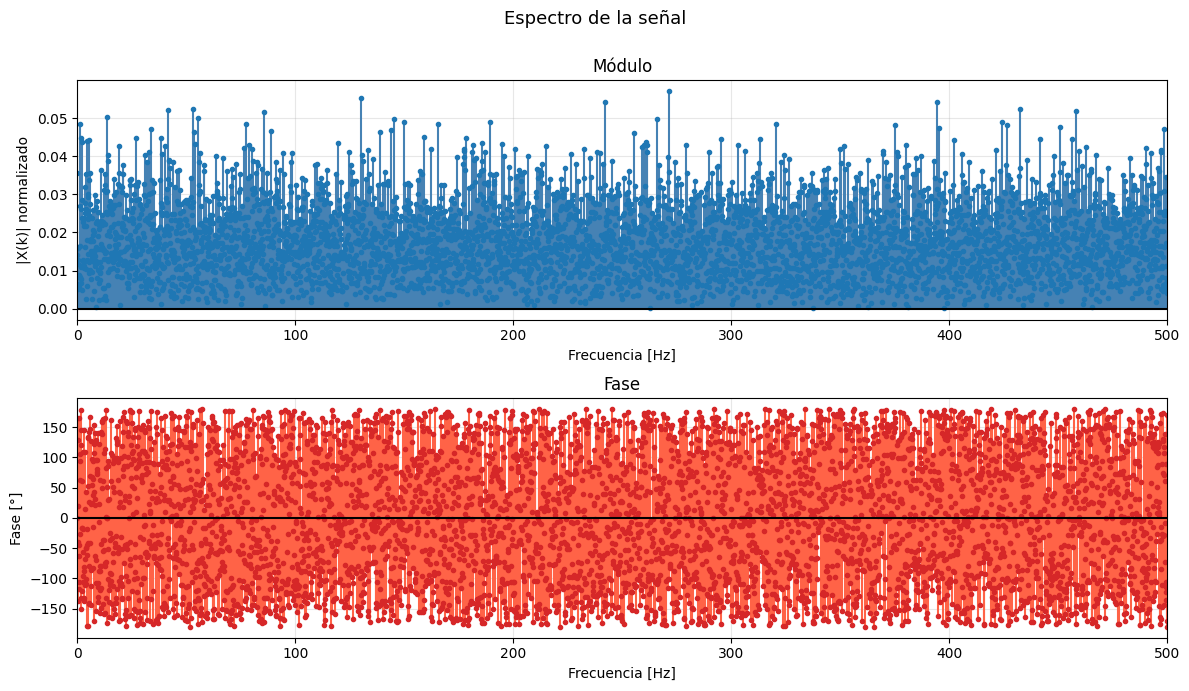

In [48]:
N = 10000
t, x = unoise(nn=N, fs=fs, mean=0, std=2)
xt = x.reshape((N, 1)) # La funcion DFT usa (N,1)
Xk = dft(xt)
k  = np.arange(N) # Tiene simetria con respecto a N/2
f  = k * fs / N
               
modulo     = np.abs(Xk[k])  / N  # Normalizamos
fase       = np.angle(Xk[k]) # En Radianes

fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(12, 7))
fig2.suptitle("Espectro de la señal", fontsize=13)

ax2.stem(f, modulo, linefmt='steelblue', markerfmt='C0.', basefmt='k')
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("|X(k)| normalizado")
ax2.set_title("Módulo")
ax2.set_xlim(0, fs/2)
ax2.grid(True, alpha=0.3)

ax3.stem(f, np.degrees(fase), linefmt='tomato', markerfmt='C3.', basefmt='k')
ax3.set_xlabel("Frecuencia [Hz]")
ax3.set_ylabel("Fase [°]")
ax3.set_title("Fase")
ax3.set_xlim(0, fs/2)
ax3.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.subplots_adjust(top=0.88)

plt.show()